# Untreated CoCulture Math Modelling (Simplified)

This notebook is a clean, standalone version for untreated coculture fitting.

Fixed monoculture baselines used:
- Naive/non_cis: Logistic with `r = 0.8725`, `K = 3947.9117`, `v = 1.0`
- Resistant/cis: Theta-logistic with `r = 0.4286`, `K = 3798.7457`, `v = 5.0`

The notebook fits only interaction terms for two coculture models:
1. Competitive interaction model (`alpha_SR`, `alpha_RS`)
2. Shared carrying capacity model (`K_shared`)

In [1]:
import Pkg

const NOTEBOOK_ENV = joinpath(pwd(), ".julia_env")
if isdir(NOTEBOOK_ENV)
    Pkg.activate(NOTEBOOK_ENV)
    println("Activated notebook env: " * NOTEBOOK_ENV)
    try
        Pkg.instantiate()
        Pkg.precompile()
    catch e
        println("Warning during instantiate/precompile: " * sprint(showerror, e))
    end
else
    println("Warning: notebook env not found at " * NOTEBOOK_ENV)
    println("Using current active env: " * Base.active_project())
end

const REQUIRED_PKGS = [
    "CSV",
    "DataFrames",
    "Statistics",
    "Optim",
    "Plots",
    "SciMLBase",
    "OrdinaryDiffEq",
]

function import_pkg(pkg::String)
    try
        Base.eval(Main, :(import $(Symbol(pkg))))
        println("Loaded: " * pkg)
        return true
    catch e
        println("Initial load failed for " * pkg * ": " * sprint(showerror, e))
        return false
    end
end

function ensure_pkg_loaded(pkg::String)
    import_pkg(pkg) && return true
    if pkg == "Statistics"
        return false
    end

    println("Attempting to install/recover package: " * pkg)
    try
        Pkg.add(pkg)
        Pkg.instantiate()
        Pkg.precompile()
    catch e
        println("Pkg operations failed for " * pkg * ": " * sprint(showerror, e))
    end

    return import_pkg(pkg)
end

loaded = Dict{String,Bool}()
for pkg in REQUIRED_PKGS
    loaded[pkg] = ensure_pkg_loaded(pkg)
end

missing_pkgs = [p for p in REQUIRED_PKGS if !loaded[p]]
if !isempty(missing_pkgs)
    println("\nPackages still unavailable: " * join(missing_pkgs, ", "))
    println("Run in Julia REPL if needed:")
    println("using Pkg; Pkg.activate(raw\"" * NOTEBOOK_ENV * "\"); Pkg.instantiate(); Pkg.add(" * repr(missing_pkgs) * "); Pkg.precompile()")
end

if get(loaded, "Plots", false)
    try
        Plots.default(linewidth = 2, legend = :topright, framestyle = :box)
    catch e
        println("Could not set Plots defaults: " * sprint(showerror, e))
    end
end

println("Active Julia env: " * Base.active_project())

  Activating project at `d:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env`


Activated notebook env: d:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env


   Installed Statistics ─────────────────── v1.11.1
   Installed OrdinaryDiffEqFIRK ─────────── v1.23.0
   Installed OrdinaryDiffEqNonlinearSolve ─ v1.23.0
   Installed OrdinaryDiffEqBDF ──────────── v1.21.0
   Installed OrdinaryDiffEqRosenbrock ───── v1.25.0
   Installed OrdinaryDiffEqRKN ──────────── v1.10.0
   Installed DiffEqBase ─────────────────── v6.210.0
   Installed PrecompileTools ────────────── v1.3.3
Precompiling packages...
   1059.4 ms  ✓ ConcreteStructs
   1073.3 ms  ✓ MuladdMacro
   1214.9 ms  ✓ PositiveFactorizations
   1319.2 ms  ✓ ExprTools
    889.1 ms  ✓ IteratorInterfaceExtensions
   1644.9 ms  ✓ ADTypes
   1312.1 ms  ✓ InverseFunctions
   2307.5 ms  ✓ FillArrays
   4354.6 ms  ✓ FunctionWrappers
   1509.6 ms  ✓ Statistics
   1086.9 ms  ✓ CommonSolve
    991.9 ms  ✓ ManualMemory
   1590.0 ms  ✓ Requires
    981.6 ms  ✓ EnumX
    936.7 ms  ✓ Reexport
    978.3 ms  ✓ SIMDTypes
   6362.2 ms  ✓ ExproniconLite
   3805.1 ms  ✓ OrderedCollections
   1442.8 ms  ✓ DocString

Initial load failed for CSV: ArgumentError: Package CSV not found in current path.
- Run `import Pkg; Pkg.add("CSV")` to install the CSV package.
Attempting to install/recover package: CSV


    Updating registry at `C:\Users\elbak\.julia\registries\General.toml`
   Resolving package versions...
    Updating `D:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env\Project.toml`
  [336ed68f] + CSV v0.10.16
    Updating `D:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env\Manifest.toml`
  [336ed68f] + CSV v0.10.16
  [944b1d66] + CodecZlib v0.7.8
  [9a962f9c] + DataAPI v1.16.0
  [e2d170a0] + DataValueInterfaces v1.0.0
  [48062228] + FilePathsBase v0.9.24
  [842dd82b] + InlineStrings v1.4.5
  [69de0a69] + Parsers v2.8.3
  [2dfb63ee] + PooledArrays v1.4.3
  [91c51154] + SentinelArrays v1.4.9
  [3783bdb8] + TableTraits v1.0.1
  [bd369af6] + Tables v1.12.1
  [3bb67fe8] + TranscodingStreams v0.11.3
  [ea10d353] + WeakRefStrings v1.4.2
  [76eceee3] + WorkerUtilities v1.6.1
  [a63ad114] + Mmap v1.11.0
Precompiling packages...
   1322.8 ms  ✓ TableTraits
   1468.7 ms  ✓ WorkerUti

Loaded: CSV
Initial load failed for DataFrames: ArgumentError: Package DataFrames not found in current path.
- Run `import Pkg; Pkg.add("DataFrames")` to install the DataFrames package.
Attempting to install/recover package: DataFrames


   Resolving package versions...
    Updating `D:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env\Project.toml`
  [a93c6f00] + DataFrames v1.8.1
    Updating `D:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env\Manifest.toml`
  [a8cc5b0e] + Crayons v4.1.1
  [a93c6f00] + DataFrames v1.8.1
  [41ab1584] + InvertedIndices v1.3.1
  [b964fa9f] + LaTeXStrings v1.4.0
  [e1d29d7a] + Missings v1.2.0
  [08abe8d2] + PrettyTables v3.2.3
  [a2af1166] + SortingAlgorithms v1.2.2
  [892a3eda] + StringManipulation v0.4.2
  [3fa0cd96] + REPL v1.11.0
Precompiling packages...
   2503.3 ms  ✓ LaTeXStrings
   1375.6 ms  ✓ InvertedIndices
   1453.1 ms  ✓ SortingAlgorithms
   3124.2 ms  ✓ Missings
   4468.6 ms  ✓ Crayons
   3517.3 ms  ✓ StringManipulation
  35506.5 ms  ✓ PrettyTables
   1841.6 ms  ✓ SymbolicIndexingInterface → SymbolicIndexingInterfacePrettyTablesExt
  71022.6 ms  ✓ DataFrames
  9 dep

Loaded: DataFrames
Loaded: Statistics
Loaded: Optim
Initial load failed for Plots: ArgumentError: Package Plots not found in current path.
- Run `import Pkg; Pkg.add("Plots")` to install the Plots package.
Attempting to install/recover package: Plots


   Resolving package versions...
   Installed MbedTLS_jll ─ v2.28.1010+0
   Installed MbedTLS ───── v1.1.10
  Installing 1 artifacts
   Installed artifact MbedTLS               6.7 MiB
    Updating `D:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env\Project.toml`
  [91a5bcdd] + Plots v1.41.6
    Updating `D:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env\Manifest.toml`
  [66dad0bd] + AliasTables v1.1.3
  [d1d4a3ce] + BitFlags v0.1.9
  [35d6a980] + ColorSchemes v3.31.0
  [3da002f7] + ColorTypes v0.12.1
  [c3611d14] + ColorVectorSpace v0.11.0
  [5ae59095] + Colors v0.13.1
  [f0e56b4a] + ConcurrentUtilities v2.5.1
  [d38c429a] + Contour v0.6.3
  [8bb1440f] + DelimitedFiles v1.9.1
  [460bff9d] + ExceptionUnwrapping v0.1.11
  [c87230d0] + FFMPEG v0.4.5
  [53c48c17] + FixedPointNumbers v0.8.5
  [1fa38f19] + Format v1.3.7
  [28b8d3ca] + GR v0.73.22
  [42e2da0e] + Grisu v1.0.2
  [cd

Loaded: Plots
Loaded: SciMLBase
Loaded: OrdinaryDiffEq
Active Julia env: d:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env\Project.toml


In [2]:
# Paths + file discovery
project_root = dirname(dirname(pwd()))
coculture_root = joinpath(project_root, "Processed_Datasets", "Untreated CoCulture")
seeding_levels = ("20k", "30k")
roots = [joinpath(coculture_root, s) for s in seeding_levels]

@assert isdir(project_root) "project_root missing: $project_root"
@assert isdir(coculture_root) "coculture_root missing: $coculture_root"

function collect_day_average_files(roots::Vector{String})
    files = String[]
    for r in roots
        isdir(r) || continue
        for (root, _, filelist) in walkdir(r)
            for f in filelist
                endswith(f, "day_averages.csv") || continue
                push!(files, joinpath(root, f))
            end
        end
    end
    return sort(files)
end

all_day_average_files = collect_day_average_files(roots)
@assert !isempty(all_day_average_files) "No day-average files found."
println("Found $(length(all_day_average_files)) day-average files")

Found 24 day-average files


In [17]:
# Data loading (self-contained + rerun-safe)
using CSV, DataFrames

@assert @isdefined(all_day_average_files) "Run Cell 3 first to define all_day_average_files"

if !@isdefined(CoCultureDataset)
    struct CoCultureDataset
        density::String
        mix_label::String
        t::Vector{Float64}
        cis::Vector{Float64}
        non_cis::Vector{Float64}
    end
end

if !@isdefined(USE_WELL_LEVEL)
    const USE_WELL_LEVEL = false
end
if !@isdefined(DAY_SUFFIX)
    const DAY_SUFFIX = "_day_averages.csv"
end
if !@isdefined(WELL_DAY_SUFFIX)
    const WELL_DAY_SUFFIX = "_well_day_averages.csv"
end

function parse_density_compartment(path::AbstractString)
    parts = splitpath(path)
    idx = findfirst(==("Untreated CoCulture"), parts)
    idx === nothing && error("Could not find 'Untreated CoCulture' in path: $path")
    density = parts[idx + 1]
    compartment = parts[idx + 2]
    return density, compartment
end

function parse_mix_label(path::AbstractString)
    fname = splitpath(path)[end]
    m = match(r"measure_([0-9]+-[0-9]+)", fname)
    return m === nothing ? "unknown" : m.captures[1]
end

function detect_time_count_cols(df::DataFrame)
    names_df  = names(df)
    names_str = [lowercase(String(n)) for n in names_df]

    t_idx = findfirst(s -> s in ("day", "time"), names_str)
    t_idx === nothing && error("No time/day column found")

    if USE_WELL_LEVEL
        target_counts = ("mean_cells", "day_mean_cells", "avg_count")
    else
        target_counts = ("day_mean_cells", "mean_cells", "avg_count")
    end
    c_idx = findfirst(s -> s in target_counts, names_str)
    c_idx === nothing && error("No count column found")

    return names_df[t_idx], names_df[c_idx]
end

function load_single_compartment(file::String)
    df = CSV.read(file, DataFrame)
    tcol, ccol = detect_time_count_cols(df)
    t = Float64.(df[!, tcol])
    counts = Float64.(df[!, ccol])
    return t, counts
end

day0_total_baseline(density::String) = density == "20k" ? 67.0 : density == "30k" ? 100.0 : error("No day0 baseline for $density")

function mix_fraction(mix_label::String, compartment::String)
    parts = split(mix_label, '-')
    length(parts) == 2 || error("Unexpected mix format: $mix_label")
    a = parse(Float64, parts[1])
    b = parse(Float64, parts[2])
    tot = a + b
    compartment == "cis" && return a / tot
    compartment == "non_cis" && return b / tot
    error("Unknown compartment: $compartment")
end

function load_coculture_datasets(all_files::Vector{String})
    by_key = Dict{Tuple{String,String,String},String}()
    for f in all_files
        fname = splitpath(f)[end]
        if USE_WELL_LEVEL
            endswith(fname, WELL_DAY_SUFFIX) || continue
        else
            endswith(fname, DAY_SUFFIX) || continue
            occursin("_well_", fname) && continue
        end
        density, compartment = parse_density_compartment(f)
        mix = parse_mix_label(f)
        by_key[(density, compartment, mix)] = f
    end

    datasets = CoCultureDataset[]
    densities = sort(unique(k[1] for k in keys(by_key)))
    mixes     = sort(unique(k[3] for k in keys(by_key)))

    for density in densities, mix in mixes
        cis_key = (density, "cis", mix)
        non_key = (density, "non_cis", mix)
        haskey(by_key, cis_key) || continue
        haskey(by_key, non_key) || continue

        t_cis, cis_vals = load_single_compartment(by_key[cis_key])
        t_non, non_vals = load_single_compartment(by_key[non_key])
        @assert length(t_cis) == length(t_non)
        @assert all(t_cis .== t_non)

        total0 = day0_total_baseline(density)
        cis0 = mix_fraction(mix, "cis") * total0
        non0 = mix_fraction(mix, "non_cis") * total0

        t_full = vcat(0.0, t_cis)
        cis_full = vcat(cis0, cis_vals)
        non_full = vcat(non0, non_vals)

        push!(datasets, CoCultureDataset(density, mix, t_full, cis_full, non_full))
    end

    @assert !isempty(datasets) "No matched cis/non_cis datasets found"
    return datasets
end

datasets = load_coculture_datasets(all_day_average_files)
println("Loaded $(length(datasets)) matched datasets")
first(datasets)

Loaded 6 matched datasets


CoCultureDataset("20k", "25-75", [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0], [16.75, 31.28, 54.13, 91.82, 189.74, 391.3, 609.7, 844.84, 1041.48, 1339.68, 1081.78, 1735.17, 986.34, 1465.85, 1085.67], [50.25, 12.81, 36.59, 105.56, 270.23, 849.87, 860.26, 1553.25, 1776.56, 1648.92, 2098.65, 2367.12, 2250.22, 2750.68, 2685.17])

In [18]:
# Models + fitting (expanded model zoo; self-contained + rerun-safe)
import Pkg
const NOTEBOOK_ENV = joinpath(pwd(), ".julia_env")
isdir(NOTEBOOK_ENV) && Pkg.activate(NOTEBOOK_ENV)

using Optim, DataFrames, Statistics, Random, CSV

@assert @isdefined(CoCultureDataset) "Run Cell 4 first to define CoCultureDataset and datasets"

try
    import SciMLBase
    import OrdinaryDiffEq
catch e
    error("SciMLBase/OrdinaryDiffEq are required for ODE simulation. Activate env: using Pkg; Pkg.activate(raw\"$(NOTEBOOK_ENV)\"). Then install if needed: Pkg.add([\"SciMLBase\",\"OrdinaryDiffEq\"]). Original error: $(sprint(showerror, e))")
end

Random.seed!(1)

const FIT_SAFEGUARDS = (
    n_starts = 12,
    prescreen_keep = 4,
    max_opt_iters = 350,
    per_start_time_limit_s = 4.0,
    ode_maxiters = 200_000,
    fail_penalty = 1e12,
)

if !@isdefined(CoCultureModel)
    abstract type CoCultureModel end
end

const MONO_PARAM_SOURCE = joinpath(dirname(pwd()), "Untreated MonoCulture", "outputs", "csv", "monoculture_model_bic_results.csv")
const MONO_PARAM_SELECTION = (
    non_cis = (cell_line = "naive", model = "logistic_shared_rk"),
    cis     = (cell_line = "resistant", model = "theta_logistic_shared_rk"),
)

function parse_param_vector(param_text::AbstractString)
    txt = strip(replace(replace(param_text, "[" => ""), "]" => ""))
    isempty(txt) && return Float64[]
    return parse.(Float64, strip.(split(txt, ",")))
end

function load_selected_monoculture_baselines(csv_path::AbstractString)
    isfile(csv_path) || return nothing
    df = CSV.read(csv_path, DataFrame)
    cols = Set(string.(names(df)))
    needed = Set(["cell_line", "model", "params"])
    issubset(needed, cols) || return nothing

    function pick_row(cell_line::String, model_name::String)
        sub = df[(string.(df.cell_line) .== cell_line) .& (string.(df.model) .== model_name), :]
        nrow(sub) == 0 && return nothing
        vals = parse_param_vector(String(sub.params[1]))
        length(vals) >= 2 || return nothing
        return (r = vals[1], K = vals[2], v = length(vals) >= 3 ? vals[3] : 1.0)
    end

    b_non = pick_row(MONO_PARAM_SELECTION.non_cis.cell_line, MONO_PARAM_SELECTION.non_cis.model)
    b_cis = pick_row(MONO_PARAM_SELECTION.cis.cell_line, MONO_PARAM_SELECTION.cis.model)
    (isnothing(b_non) || isnothing(b_cis)) && return nothing
    return Dict(:non_cis => b_non, :cis => b_cis)
end

if !@isdefined(FIXED_MONO_BASELINES)
    default_baselines = Dict(
        :non_cis => (r = 0.8725, K = 3947.9117, v = 1.0),
        :cis     => (r = 0.4286, K = 3798.7457, v = 5.0),
    )

    loaded_baselines = try
        load_selected_monoculture_baselines(MONO_PARAM_SOURCE)
    catch err
        println("Warning: failed to read monoculture baselines from source CSV: " * sprint(showerror, err))
        nothing
    end

    if isnothing(loaded_baselines)
        const FIXED_MONO_BASELINES = default_baselines
        println("Using embedded monoculture baselines (source CSV unavailable or missing selected rows).")
    else
        const FIXED_MONO_BASELINES = loaded_baselines
        println("Loaded monoculture baselines from: " * MONO_PARAM_SOURCE)
    end
end

println("Monoculture baselines in use -> non_cis=(r=$(round(FIXED_MONO_BASELINES[:non_cis].r, digits=4)), K=$(round(FIXED_MONO_BASELINES[:non_cis].K, digits=4)), v=$(round(FIXED_MONO_BASELINES[:non_cis].v, digits=4))), cis=(r=$(round(FIXED_MONO_BASELINES[:cis].r, digits=4)), K=$(round(FIXED_MONO_BASELINES[:cis].K, digits=4)), v=$(round(FIXED_MONO_BASELINES[:cis].v, digits=4)))")

if !@isdefined(FixedMonoCompetitive)
    struct FixedMonoCompetitive <: CoCultureModel end
end
if !@isdefined(FixedMonoSharedK)
    struct FixedMonoSharedK <: CoCultureModel end
end
if !@isdefined(FixedMonoSymmetricAlpha)
    struct FixedMonoSymmetricAlpha <: CoCultureModel end
end
if !@isdefined(FixedMonoSharedKSymmetricAlpha)
    struct FixedMonoSharedKSymmetricAlpha <: CoCultureModel end
end
if !@isdefined(FixedMonoSharedKCompetitive)
    struct FixedMonoSharedKCompetitive <: CoCultureModel end
end
if !@isdefined(FixedMonoCompetitiveDeath)
    struct FixedMonoCompetitiveDeath <: CoCultureModel end
end
if !@isdefined(FixedMonoSharedKDeath)
    struct FixedMonoSharedKDeath <: CoCultureModel end
end

function rhs!(du, u, p, t, ::FixedMonoCompetitive)
    S, R = u
    alpha_SR, alpha_RS = p
    bS = FIXED_MONO_BASELINES[:non_cis]
    bR = FIXED_MONO_BASELINES[:cis]

    gS = max(0.0, 1 - (S + alpha_SR * R) / bS.K)
    gR = max(0.0, 1 - (alpha_RS * S + R) / bR.K)
    du[1] = bS.r * S * (gS^bS.v)
    du[2] = bR.r * R * (gR^bR.v)
    return nothing
end

function rhs!(du, u, p, t, ::FixedMonoSharedK)
    S, R = u
    K_shared = p[1]
    bS = FIXED_MONO_BASELINES[:non_cis]
    bR = FIXED_MONO_BASELINES[:cis]

    g = max(0.0, 1 - (S + R) / K_shared)
    du[1] = bS.r * S * (g^bS.v)
    du[2] = bR.r * R * (g^bR.v)
    return nothing
end

function rhs!(du, u, p, t, ::FixedMonoSymmetricAlpha)
    S, R = u
    alpha = p[1]
    bS = FIXED_MONO_BASELINES[:non_cis]
    bR = FIXED_MONO_BASELINES[:cis]

    gS = max(0.0, 1 - (S + alpha * R) / bS.K)
    gR = max(0.0, 1 - (alpha * S + R) / bR.K)
    du[1] = bS.r * S * (gS^bS.v)
    du[2] = bR.r * R * (gR^bR.v)
    return nothing
end

function rhs!(du, u, p, t, ::FixedMonoSharedKSymmetricAlpha)
    S, R = u
    K_shared, alpha = p
    bS = FIXED_MONO_BASELINES[:non_cis]
    bR = FIXED_MONO_BASELINES[:cis]

    gS = max(0.0, 1 - (S + alpha * R) / K_shared)
    gR = max(0.0, 1 - (alpha * S + R) / K_shared)
    du[1] = bS.r * S * (gS^bS.v)
    du[2] = bR.r * R * (gR^bR.v)
    return nothing
end

function rhs!(du, u, p, t, ::FixedMonoSharedKCompetitive)
    S, R = u
    K_shared, alpha_SR, alpha_RS = p
    bS = FIXED_MONO_BASELINES[:non_cis]
    bR = FIXED_MONO_BASELINES[:cis]

    gS = max(0.0, 1 - (S + alpha_SR * R) / K_shared)
    gR = max(0.0, 1 - (alpha_RS * S + R) / K_shared)
    du[1] = bS.r * S * (gS^bS.v)
    du[2] = bR.r * R * (gR^bR.v)
    return nothing
end

function rhs!(du, u, p, t, ::FixedMonoCompetitiveDeath)
    S, R = u
    alpha_SR, alpha_RS, dS, dR = p
    bS = FIXED_MONO_BASELINES[:non_cis]
    bR = FIXED_MONO_BASELINES[:cis]

    gS = max(0.0, 1 - (S + alpha_SR * R) / bS.K)
    gR = max(0.0, 1 - (alpha_RS * S + R) / bR.K)
    du[1] = bS.r * S * (gS^bS.v) - dS * S
    du[2] = bR.r * R * (gR^bR.v) - dR * R
    return nothing
end

function rhs!(du, u, p, t, ::FixedMonoSharedKDeath)
    S, R = u
    K_shared, dS, dR = p
    bS = FIXED_MONO_BASELINES[:non_cis]
    bR = FIXED_MONO_BASELINES[:cis]

    g = max(0.0, 1 - (S + R) / K_shared)
    du[1] = bS.r * S * (g^bS.v) - dS * S
    du[2] = bR.r * R * (g^bR.v) - dR * R
    return nothing
end

initial_guess(::FixedMonoCompetitive, ds::CoCultureDataset) = Float64[1.0, 1.0]
bounds(::FixedMonoCompetitive, ds::CoCultureDataset) = (Float64[0.0, 0.0], Float64[4.0, 4.0])

function initial_guess(::FixedMonoSharedK, ds::CoCultureDataset)
    return Float64[mean((FIXED_MONO_BASELINES[:non_cis].K, FIXED_MONO_BASELINES[:cis].K))]
end
bounds(::FixedMonoSharedK, ds::CoCultureDataset) = (Float64[500.0], Float64[1.0e5])

initial_guess(::FixedMonoSymmetricAlpha, ds::CoCultureDataset) = Float64[1.0]
bounds(::FixedMonoSymmetricAlpha, ds::CoCultureDataset) = (Float64[-1.5], Float64[4.0])

function initial_guess(::FixedMonoSharedKSymmetricAlpha, ds::CoCultureDataset)
    K0 = mean((FIXED_MONO_BASELINES[:non_cis].K, FIXED_MONO_BASELINES[:cis].K))
    return Float64[K0, 1.0]
end
bounds(::FixedMonoSharedKSymmetricAlpha, ds::CoCultureDataset) = (Float64[500.0, -1.5], Float64[1.0e5, 4.0])

function initial_guess(::FixedMonoSharedKCompetitive, ds::CoCultureDataset)
    K0 = mean((FIXED_MONO_BASELINES[:non_cis].K, FIXED_MONO_BASELINES[:cis].K))
    return Float64[K0, 1.0, 1.0]
end
bounds(::FixedMonoSharedKCompetitive, ds::CoCultureDataset) = (Float64[500.0, -1.5, -1.5], Float64[1.0e5, 4.0, 4.0])

initial_guess(::FixedMonoCompetitiveDeath, ds::CoCultureDataset) = Float64[1.0, 1.0, 0.01, 0.01]
bounds(::FixedMonoCompetitiveDeath, ds::CoCultureDataset) = (Float64[0.0, 0.0, 0.0, 0.0], Float64[4.0, 4.0, 1.0, 1.0])

function initial_guess(::FixedMonoSharedKDeath, ds::CoCultureDataset)
    K0 = mean((FIXED_MONO_BASELINES[:non_cis].K, FIXED_MONO_BASELINES[:cis].K))
    return Float64[K0, 0.01, 0.01]
end
bounds(::FixedMonoSharedKDeath, ds::CoCultureDataset) = (Float64[500.0, 0.0, 0.0], Float64[1.0e5, 1.0, 1.0])

function simulate_model(model::CoCultureModel, ds::CoCultureDataset, p_vec::AbstractVector;
    abstol::Float64 = 1e-8,
    reltol::Float64 = 1e-6,
    ode_maxiters::Int = FIT_SAFEGUARDS.ode_maxiters
)
    u0 = [ds.non_cis[1], ds.cis[1]]
    tspan = (first(ds.t), last(ds.t))
    f!(du, u, p, t) = rhs!(du, u, p, t, model)
    prob = SciMLBase.ODEProblem(f!, u0, tspan, collect(p_vec))

    sol = OrdinaryDiffEq.solve(prob, OrdinaryDiffEq.AutoTsit5(OrdinaryDiffEq.Rosenbrock23());
        saveat = ds.t,
        abstol = abstol,
        reltol = reltol,
        maxiters = ode_maxiters,
        verbose = false)

    SciMLBase.successful_retcode(sol) || error("ODE solve failed with retcode $(sol.retcode)")
    return ds.t, Array(sol[1, :]), Array(sol[2, :])
end

function sse_log(model::CoCultureModel, p_vec::AbstractVector, ds::CoCultureDataset; eps::Float64 = 1.0)
    penalty = FIT_SAFEGUARDS.fail_penalty
    t = nothing; S = nothing; R = nothing
    try
        t, S, R = simulate_model(model, ds, p_vec)
    catch
        return penalty
    end

    if length(S) != length(ds.non_cis) || length(R) != length(ds.cis)
        return penalty
    end

    if any(.!isfinite.(S)) || any(.!isfinite.(R)) || any(S .<= -eps) || any(R .<= -eps)
        return penalty
    end

    errS = log.(S .+ eps) .- log.(ds.non_cis .+ eps)
    errR = log.(R .+ eps) .- log.(ds.cis .+ eps)
    return sum(errS.^2 .+ errR.^2)
end

if !@isdefined(ModelSpec)
    struct ModelSpec
        name::String
        model::CoCultureModel
    end
end

ACTIVE_MODEL_SPECS = ModelSpec[
    ModelSpec("fixed_mono_competitive_log", FixedMonoCompetitive()),
    ModelSpec("fixed_mono_sharedK_log", FixedMonoSharedK()),
    ModelSpec("fixed_mono_symmetric_alpha_log", FixedMonoSymmetricAlpha()),
    ModelSpec("fixed_mono_sharedK_symmetric_alpha_log", FixedMonoSharedKSymmetricAlpha()),
    ModelSpec("fixed_mono_sharedK_competitive_log", FixedMonoSharedKCompetitive()),
    ModelSpec("fixed_mono_competitive_death_log", FixedMonoCompetitiveDeath()),
    ModelSpec("fixed_mono_sharedK_death_log", FixedMonoSharedKDeath())
]

function get_model_by_name(name::AbstractString)
    for spec in ACTIVE_MODEL_SPECS
        if spec.name == name
            return spec.model
        end
    end
    error("Unknown model: $name")
end

function fit_model(spec::ModelSpec, ds::CoCultureDataset;
    n_starts::Int = FIT_SAFEGUARDS.n_starts,
    prescreen_keep::Int = FIT_SAFEGUARDS.prescreen_keep,
    max_opt_iters::Int = FIT_SAFEGUARDS.max_opt_iters,
    per_start_time_limit_s::Float64 = FIT_SAFEGUARDS.per_start_time_limit_s
)
    p0 = initial_guess(spec.model, ds)
    lb, ub = bounds(spec.model, ds)

    loss(p) = sse_log(spec.model, p, ds; eps = 1.0)

    seeds = Vector{Vector{Float64}}()
    push!(seeds, copy(p0))
    for _ in 1:(max(n_starts, 1) - 1)
        push!(seeds, lb .+ rand(length(lb)) .* (ub .- lb))
    end

    scored = Tuple{Float64, Vector{Float64}}[]
    for init in seeds
        v = loss(init)
        isfinite(v) && push!(scored, (v, init))
    end

    if isempty(scored)
        best_val = FIT_SAFEGUARDS.fail_penalty
        best_p = copy(p0)
        best_conv = false
    else
        sort!(scored, by = x -> x[1])
        keep_n = min(max(prescreen_keep, 1), length(scored))
        candidate_seeds = [copy(scored[i][2]) for i in 1:keep_n]

        best_val = Inf
        best_p = copy(scored[1][2])
        best_conv = false

        for init in candidate_seeds
            start_t = time()
            res = try
                Optim.optimize(loss, lb, ub, init,
                    Optim.Fminbox(Optim.NelderMead()),
                    Optim.Options(
                        iterations = max_opt_iters,
                        show_trace = false,
                        callback = _ -> (time() - start_t) > per_start_time_limit_s,
                    ))
            catch
                nothing
            end
            isnothing(res) && continue

            val = Optim.minimum(res)
            if isfinite(val) && val < best_val
                best_val = val
                best_p = collect(Optim.minimizer(res))
                best_conv = Optim.converged(res)
            end
        end

        if !isfinite(best_val)
            best_val = FIT_SAFEGUARDS.fail_penalty
            best_p = copy(p0)
            best_conv = false
        end
    end

    n = max(2 * length(ds.t), 1)
    k = length(best_p)
    sigma2 = max(best_val / n, eps(Float64))
    aic = n * log(sigma2) + 2k
    bic = n * log(sigma2) + k * log(n)

    ptxt = "[" * join(round.(best_p, digits = 6), ", ") * "]"

    return (
        density = ds.density,
        mix = ds.mix_label,
        model = spec.name,
        params = ptxt,
        sse = best_val,
        aic = aic,
        bic = bic,
        converged = best_conv
    )
end

println("Expanded model-zoo setup ready. Models: " * join([s.name for s in ACTIVE_MODEL_SPECS], ", "))
println("Fit safeguards: starts=$(FIT_SAFEGUARDS.n_starts), prescreen_keep=$(FIT_SAFEGUARDS.prescreen_keep), max_opt_iters=$(FIT_SAFEGUARDS.max_opt_iters), per_start_time_limit_s=$(FIT_SAFEGUARDS.per_start_time_limit_s), ode_maxiters=$(FIT_SAFEGUARDS.ode_maxiters)")
println("ODE solve mode: AutoTsit5(Rosenbrock23), verbose=false, failed retcodes penalized")
println("Active env: " * Base.active_project())

Monoculture baselines in use -> non_cis=(r=0.8725, K=3947.9117, v=1.0), cis=(r=0.4286, K=3798.7457, v=5.0)


  Activating project at `d:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env`


Expanded model-zoo setup ready. Models: fixed_mono_competitive_log, fixed_mono_sharedK_log, fixed_mono_symmetric_alpha_log, fixed_mono_sharedK_symmetric_alpha_log, fixed_mono_sharedK_competitive_log, fixed_mono_competitive_death_log, fixed_mono_sharedK_death_log
Fit safeguards: starts=12, prescreen_keep=4, max_opt_iters=350, per_start_time_limit_s=4.0, ode_maxiters=200000
ODE solve mode: AutoTsit5(Rosenbrock23), verbose=false, failed retcodes penalized
Active env: d:\3_Research\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated CoCulture\.julia_env\Project.toml



=== Untreated CoCulture: Expanded Model Zoo Fits (sorted by BIC) ===
42×8 DataFrame
 Row │ density  mix     model                              params                             sse        aic           bic        converged 
     │ String   String  String                             String                             Float64    Float64       Float64    Bool      
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ 20k      25-75   fixed_mono_sharedK_competitive_l…  [505.186112, -1.349361, -0.48997…   10.3987   -25.7856      -21.582         true
   2 │ 20k      25-75   fixed_mono_sharedK_symmetric_alp…  [905.641423, -0.584782]             12.0347   -23.402       -20.5996        true
   3 │ 20k      25-75   fixed_mono_sharedK_death_log       [35440.463488, 0.491368, 0.0]       13.9439   -16.9846      -12.781         true
   4 │ 20k      25-75   fixed_mono_symmetric_alpha_log     [-0.190065]  

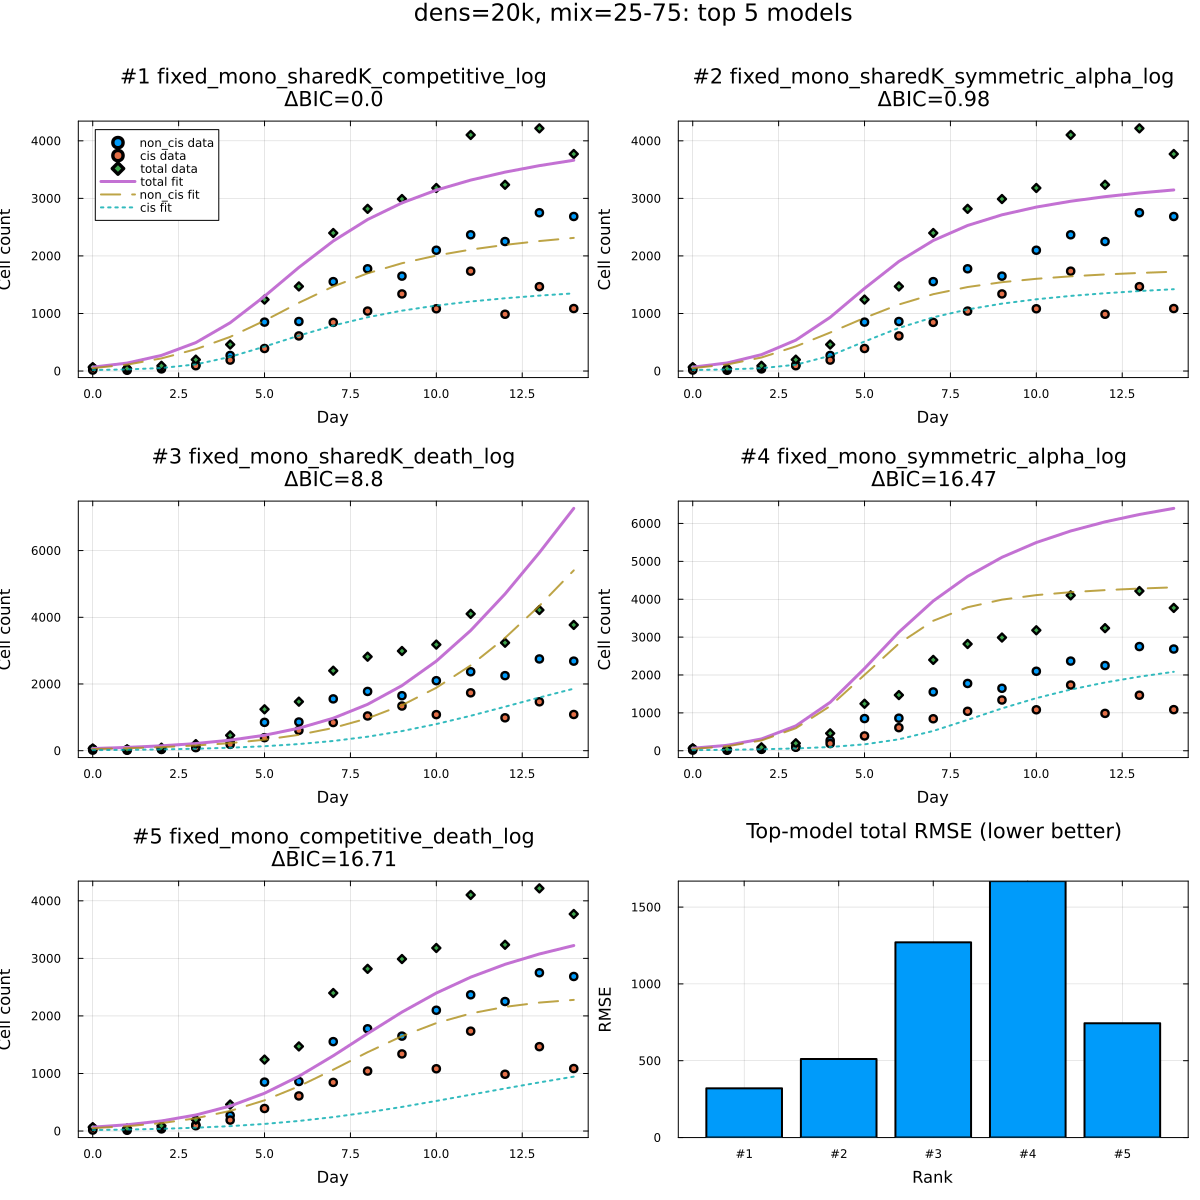

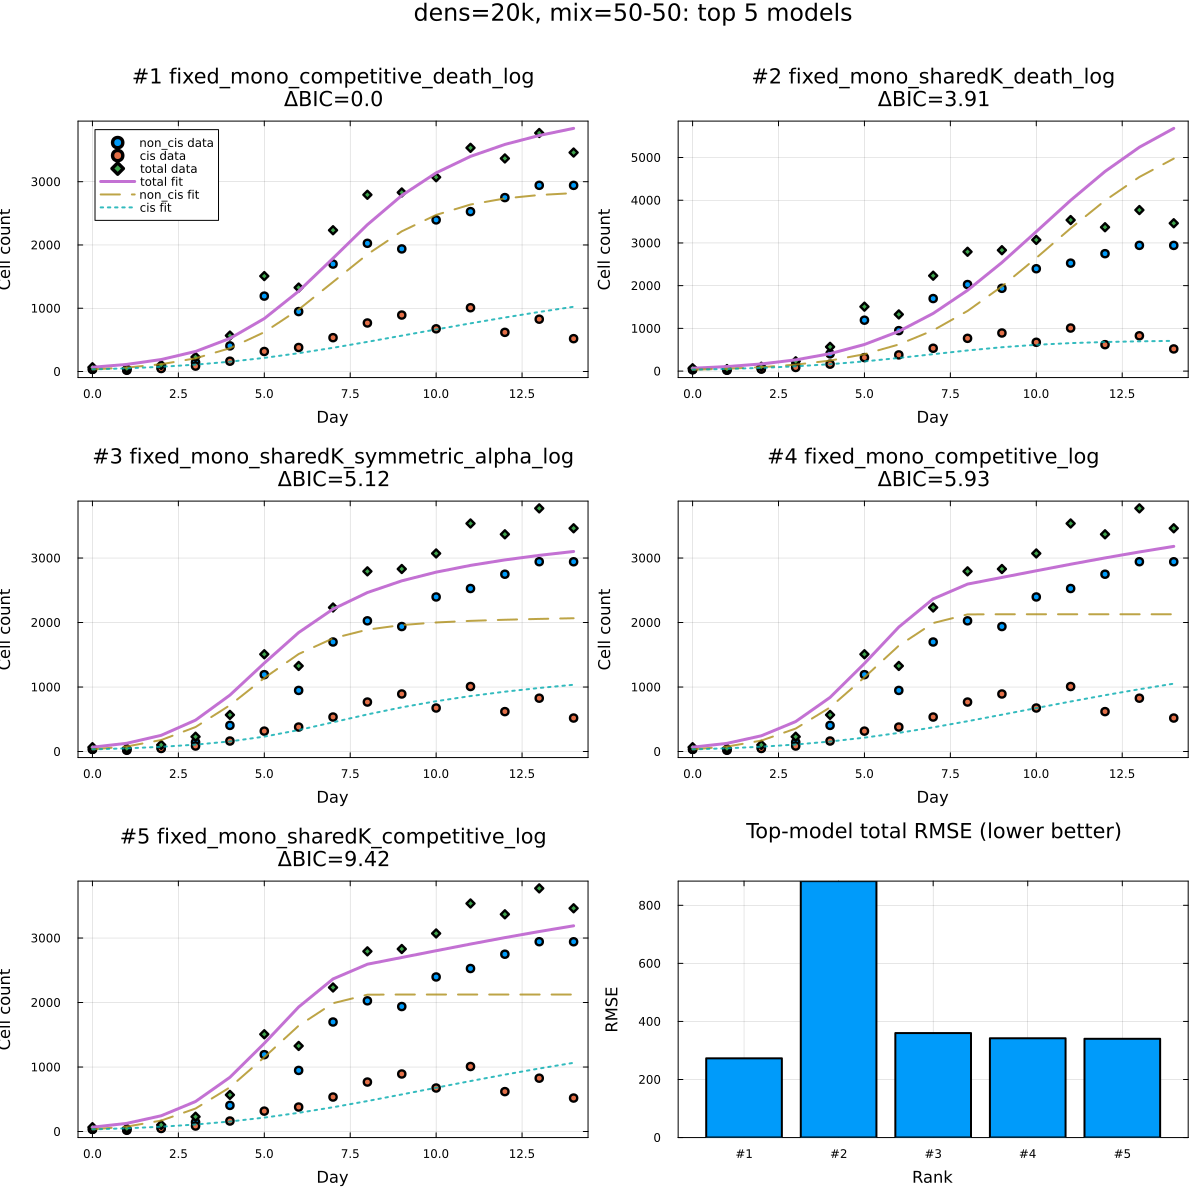

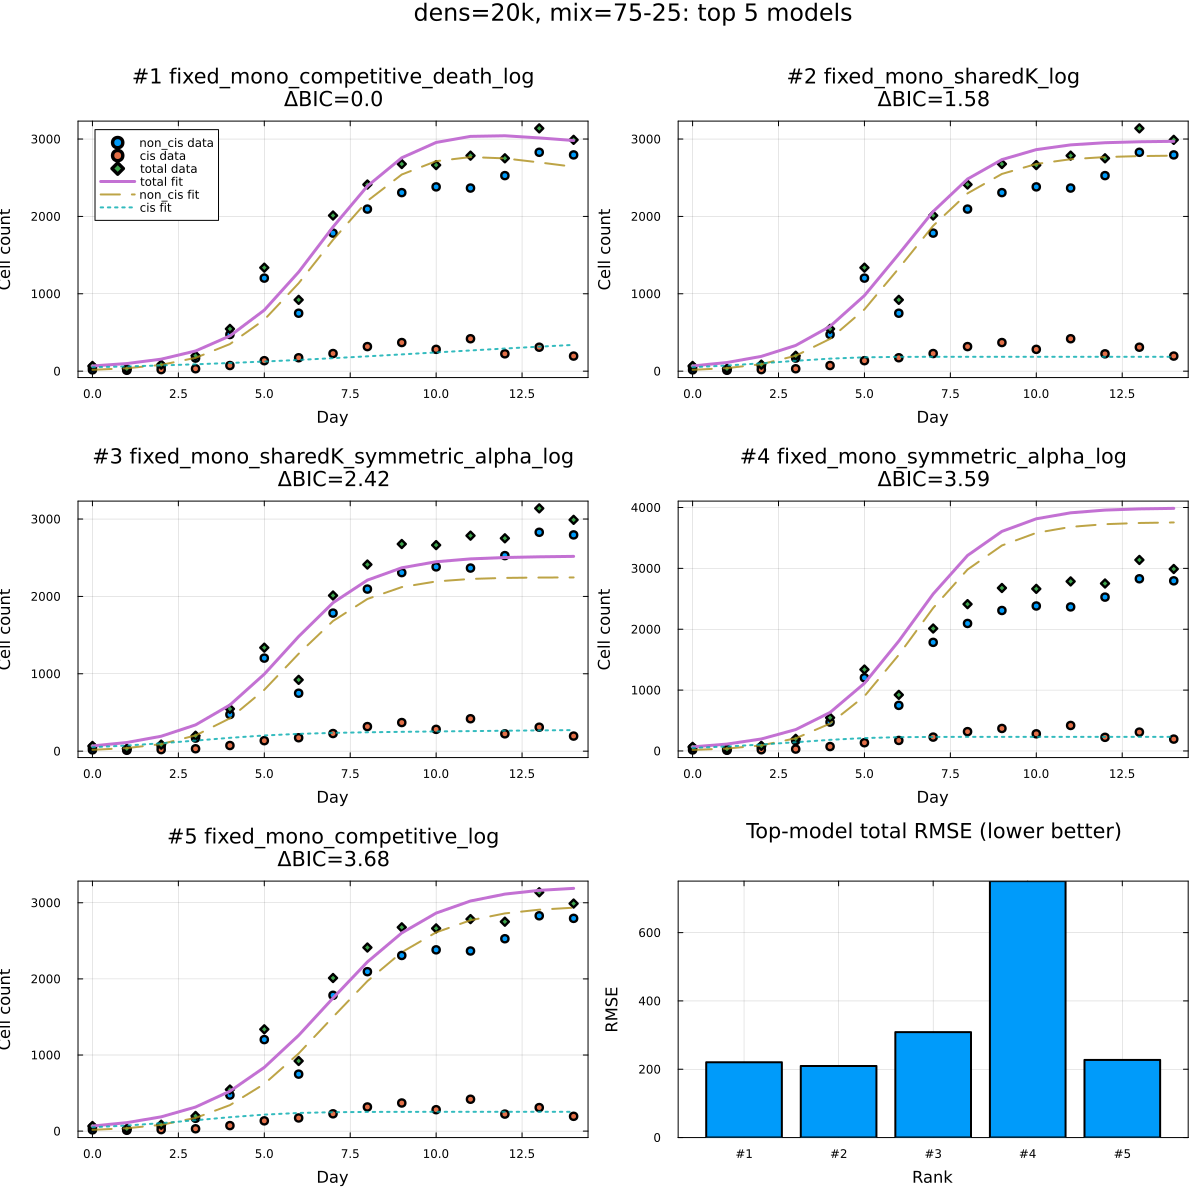

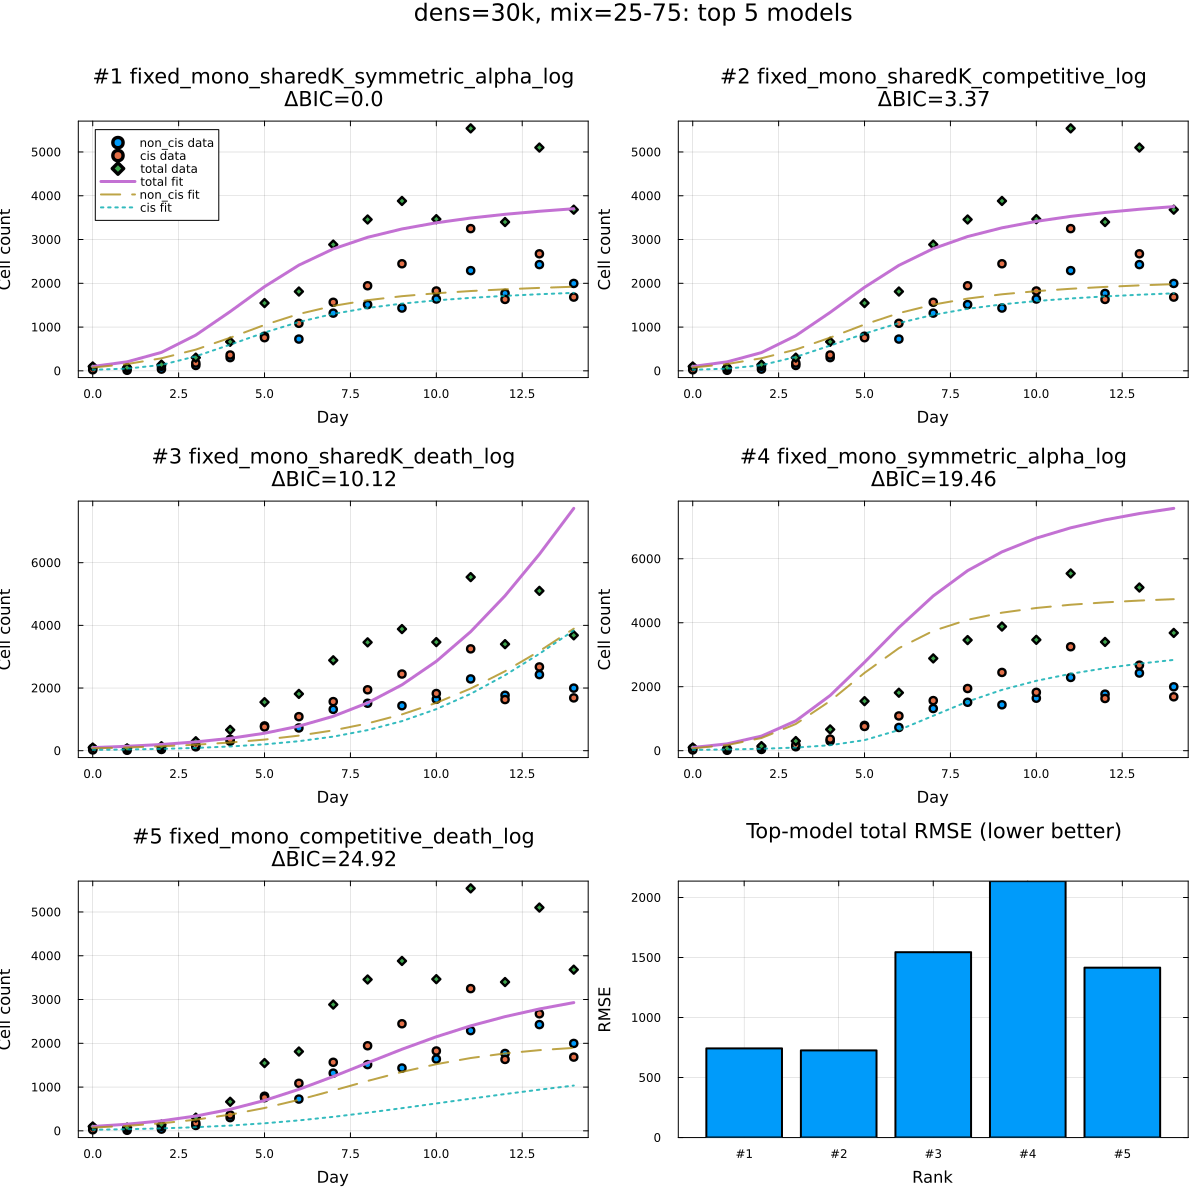

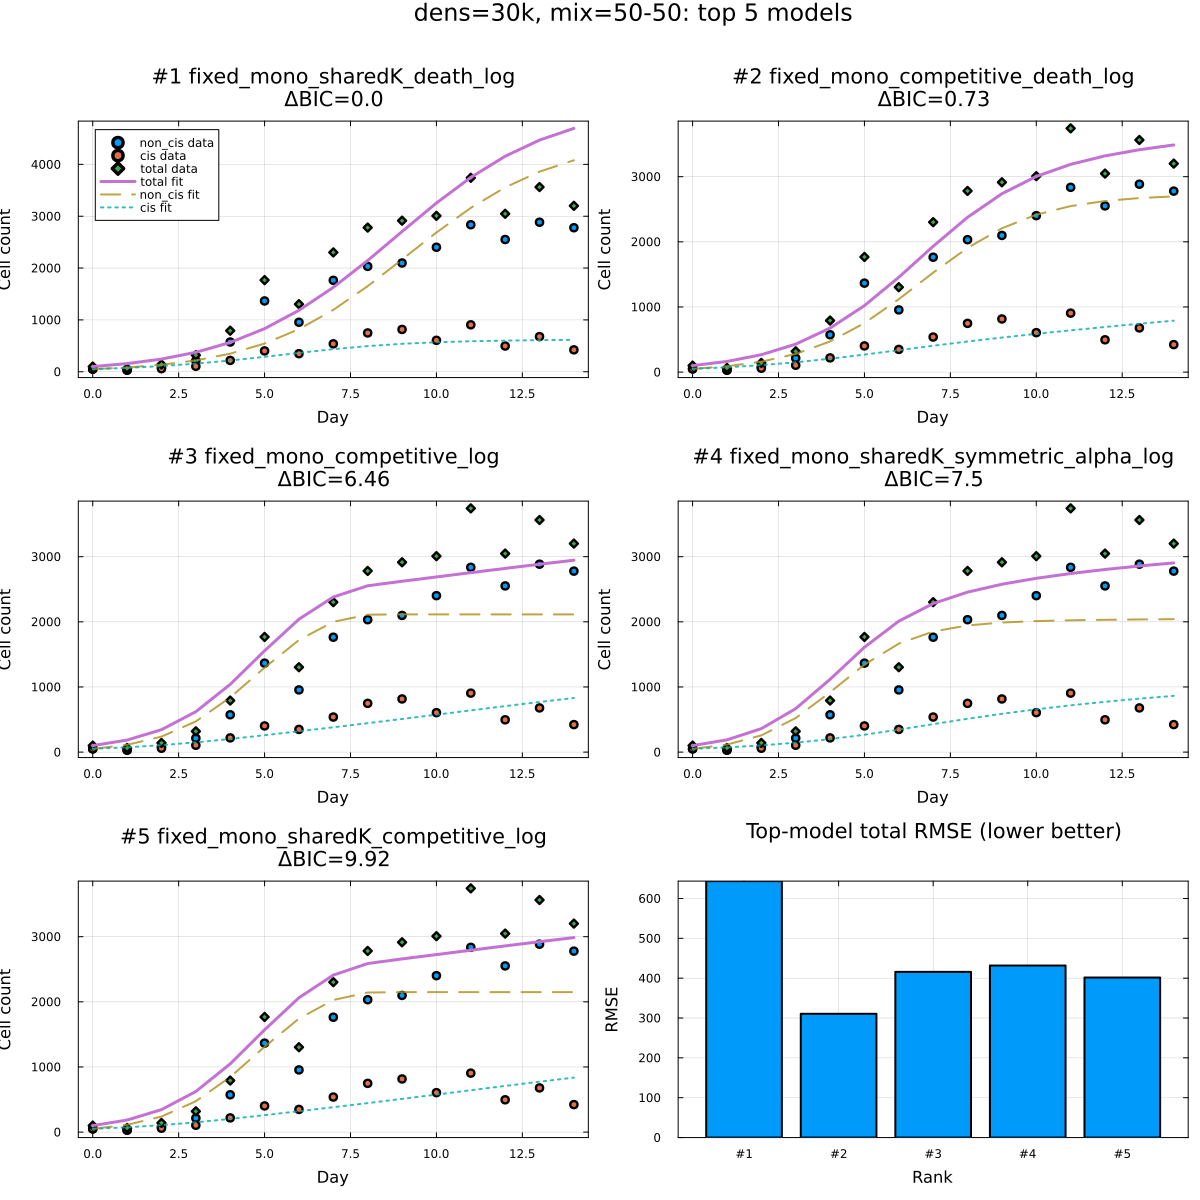

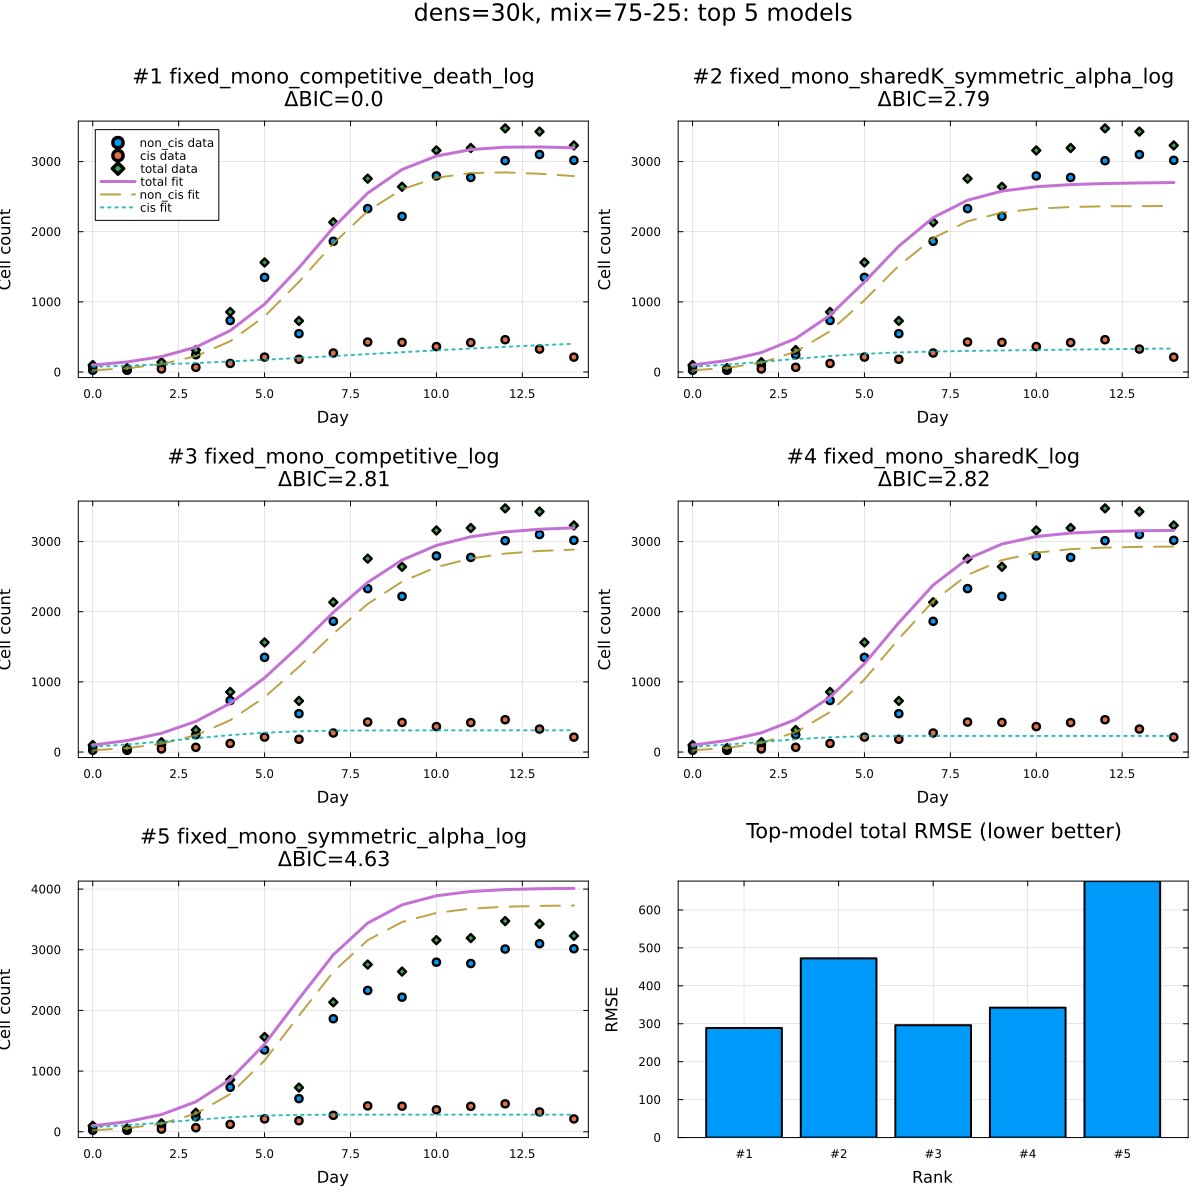

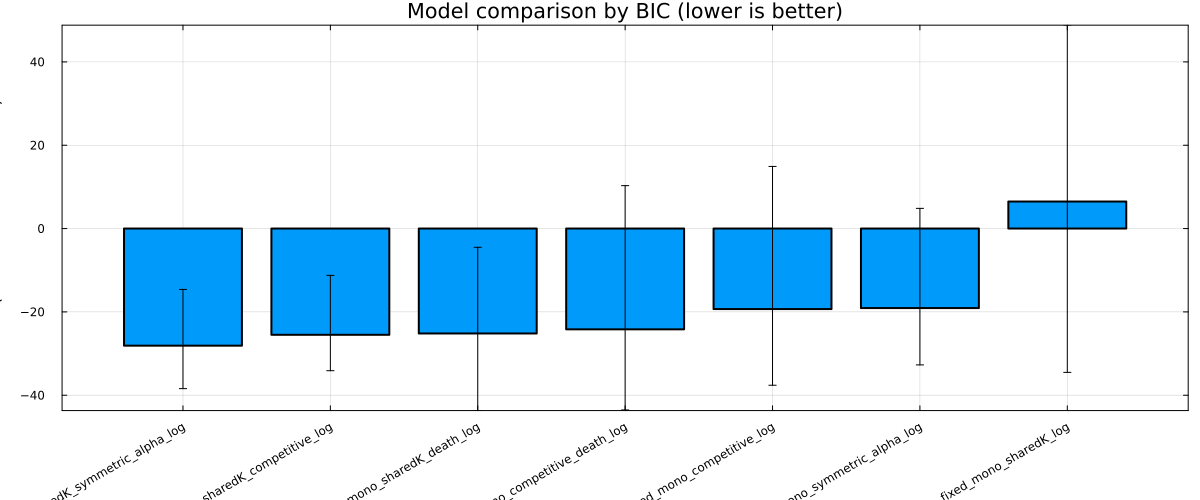

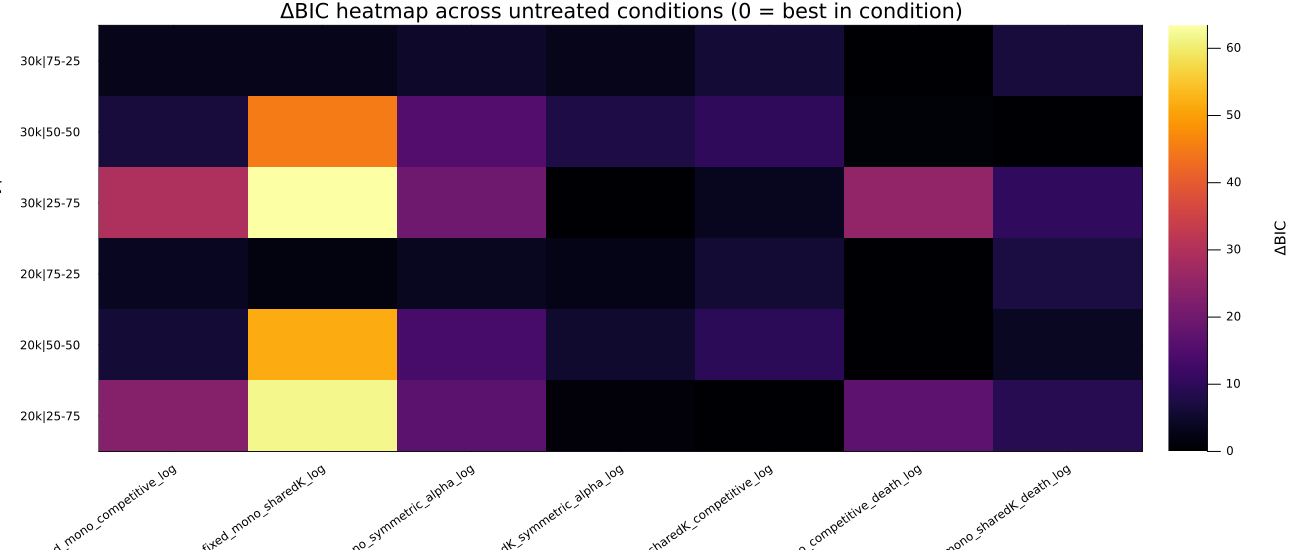

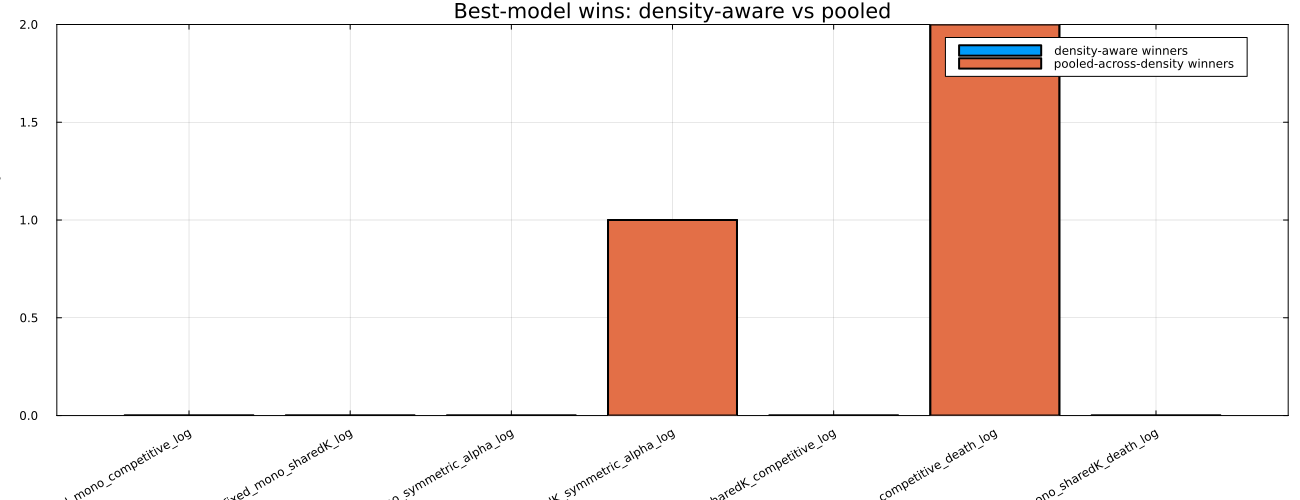

In [19]:
# Run fits + outputs + plots (expanded model-zoo output + cross-density comparisons)
# Setup is intentionally centralized in Cell 2 (environment + package loading)

@assert @isdefined(CSV) && @isdefined(DataFrames) && @isdefined(Plots) && @isdefined(Optim) "Run Cell 2 first to load required packages"
@assert @isdefined(SciMLBase) && @isdefined(OrdinaryDiffEq) "Run Cell 2 first to load SciML packages"

@assert @isdefined(datasets) "Run Cell 4 first to define datasets"
@assert @isdefined(ACTIVE_MODEL_SPECS) "Run Cell 5 first to define the expanded model specs"
@assert @isdefined(fit_model) "Run Cell 5 first to define fit_model"
@assert @isdefined(get_model_by_name) "Run Cell 5 first to define get_model_by_name"

function failed_fit_row(ds::CoCultureDataset, spec::ModelSpec, err::Any)
    println("Model failed: $(spec.name) for density=$(ds.density), mix=$(ds.mix_label)")
    println("  reason: " * sprint(showerror, err))
    n = max(2 * length(ds.t), 1)
    bad = FIT_SAFEGUARDS.fail_penalty
    return (
        density = ds.density,
        mix = ds.mix_label,
        model = spec.name,
        params = "[]",
        sse = bad,
        aic = bad + 2.0,
        bic = bad + log(n),
        converged = false
    )
end

rows = NamedTuple[]
for ds in datasets
    for spec in ACTIVE_MODEL_SPECS
        result = try
            fit_model(spec, ds)
        catch err
            failed_fit_row(ds, spec, err)
        end
        push!(rows, result)
    end
end

fit_df = DataFrame(rows)
sort!(fit_df, [:density, :mix, :bic])

println("\n=== Untreated CoCulture: Expanded Model Zoo Fits (sorted by BIC) ===")
show(fit_df, allrows = true, allcols = true)

out_csv = joinpath(pwd(), "outputs", "csv", "untreated_coculture_simplified_fits.csv")
CSV.write(out_csv, fit_df)
println("\nSaved fit table: " * out_csv)

function parse_params(ptxt::AbstractString)
    x = replace(ptxt, "[" => "", "]" => "")
    isempty(strip(x)) && return Float64[]
    return parse.(Float64, split(x, ","))
end

best_rows = combine(groupby(fit_df, [:density, :mix])) do g
    g[argmin(g.bic), :]
end
sort!(best_rows, [:density, :mix])

println("\n=== Best Model Per Condition (lowest BIC) ===")
show(best_rows, allrows = true, allcols = true)

bic_summary = combine(groupby(fit_df, :model),
    :bic => mean   => :bic_mean,
    :bic => median => :bic_median,
    :bic => minimum => :bic_min,
    :bic => maximum => :bic_max)
sort!(bic_summary, :bic_mean)

println("\n=== BIC Summary By Model ===")
show(bic_summary, allrows = true, allcols = true)

# ---------- Significance-style model comparison numbers (ΔBIC thresholds) ----------
condition_deltas = NamedTuple[]
for g in groupby(fit_df, [:density, :mix])
    gs = sort(g, :bic)
    best_bic = gs.bic[1]
    for r in eachrow(gs)
        db = r.bic - best_bic
        evidence = db >= 10 ? "decisive" : db >= 6 ? "strong" : db >= 2 ? "positive" : "weak"
        push!(condition_deltas, (
            density = r.density,
            mix = r.mix,
            model = r.model,
            bic = r.bic,
            delta_bic = db,
            evidence = evidence,
        ))
    end
end

delta_df = DataFrame(condition_deltas)
model_significance = combine(groupby(delta_df, :model),
    :delta_bic => mean => :delta_bic_mean,
    :delta_bic => median => :delta_bic_median,
    :delta_bic => (x -> count(<(2.0), x)) => :n_weak,
    :delta_bic => (x -> count(y -> y >= 2.0 && y < 6.0, x)) => :n_positive,
    :delta_bic => (x -> count(y -> y >= 6.0 && y < 10.0, x)) => :n_strong,
    :delta_bic => (x -> count(>=(10.0), x)) => :n_decisive,
)
sort!(model_significance, :delta_bic_mean)

significance_csv = joinpath(pwd(), "outputs", "csv", "untreated_coculture_model_significance_summary.csv")
CSV.write(significance_csv, model_significance)
println("\n=== Model significance summary (ΔBIC bins) ===")
show(model_significance, allrows = true, allcols = true)
println("\nSaved model significance summary: " * significance_csv)

# ---------- Cross-density fitting comparison ----------
# density-aware: separate fits per condition then aggregate by mix/model
aware_mix_df = combine(groupby(fit_df, [:mix, :model]),
    :sse => sum => :aware_sse_total,
    :bic => sum => :aware_bic_total,
    :aic => sum => :aware_aic_total,
    nrow => :n_conditions,
)

# density-agnostic pooled: one shared parameter set per model per mix across both densities
const POOLED_SAFEGUARDS = (
    n_starts = max(6, FIT_SAFEGUARDS.prescreen_keep + 2),
    prescreen_keep = min(3, FIT_SAFEGUARDS.prescreen_keep),
    max_opt_iters = min(220, FIT_SAFEGUARDS.max_opt_iters),
    per_start_time_limit_s = min(2.5, FIT_SAFEGUARDS.per_start_time_limit_s),
)

function fit_model_pooled(spec::ModelSpec, ds_group::Vector{CoCultureDataset};
    n_starts::Int = POOLED_SAFEGUARDS.n_starts,
    prescreen_keep::Int = POOLED_SAFEGUARDS.prescreen_keep,
    max_opt_iters::Int = POOLED_SAFEGUARDS.max_opt_iters,
    per_start_time_limit_s::Float64 = POOLED_SAFEGUARDS.per_start_time_limit_s
)
    @assert !isempty(ds_group)
    p0 = initial_guess(spec.model, ds_group[1])
    lb, ub = bounds(spec.model, ds_group[1])

    pooled_loss(p) = sum(sse_log(spec.model, p, ds; eps = 1.0) for ds in ds_group)

    seeds = Vector{Vector{Float64}}()
    push!(seeds, copy(p0))
    for _ in 1:(max(n_starts, 1) - 1)
        push!(seeds, lb .+ rand(length(lb)) .* (ub .- lb))
    end

    scored = Tuple{Float64, Vector{Float64}}[]
    for init in seeds
        v = pooled_loss(init)
        isfinite(v) && push!(scored, (v, init))
    end

    if isempty(scored)
        best_val = FIT_SAFEGUARDS.fail_penalty
        best_p = copy(p0)
        best_conv = false
    else
        sort!(scored, by = x -> x[1])
        keep_n = min(max(prescreen_keep, 1), length(scored))
        candidate_seeds = [copy(scored[i][2]) for i in 1:keep_n]

        best_val = Inf
        best_p = copy(scored[1][2])
        best_conv = false

        for init in candidate_seeds
            start_t = time()
            res = try
                Optim.optimize(pooled_loss, lb, ub, init,
                    Optim.Fminbox(Optim.NelderMead()),
                    Optim.Options(
                        iterations = max_opt_iters,
                        show_trace = false,
                        callback = _ -> (time() - start_t) > per_start_time_limit_s,
                    ))
            catch
                nothing
            end
            isnothing(res) && continue

            val = Optim.minimum(res)
            if isfinite(val) && val < best_val
                best_val = val
                best_p = collect(Optim.minimizer(res))
                best_conv = Optim.converged(res)
            end
        end

        if !isfinite(best_val)
            best_val = FIT_SAFEGUARDS.fail_penalty
            best_p = copy(p0)
            best_conv = false
        end
    end

    n_obs = sum(2 * length(ds.t) for ds in ds_group)
    n = max(n_obs, 1)
    k = length(best_p)
    sigma2 = max(best_val / n, eps(Float64))
    aic = n * log(sigma2) + 2k
    bic = n * log(sigma2) + k * log(n)

    ptxt = "[" * join(round.(best_p, digits = 6), ", ") * "]"
    return (params = ptxt, sse = best_val, aic = aic, bic = bic, converged = best_conv, n_obs = n)
end

mixes = sort(unique(ds.mix_label for ds in datasets))
pooled_rows = NamedTuple[]
for mix in mixes
    ds_group = [ds for ds in datasets if ds.mix_label == mix]
    for spec in ACTIVE_MODEL_SPECS
        pooled = try
            fit_model_pooled(spec, ds_group)
        catch err
            println("Pooled model failed: $(spec.name), mix=$(mix), reason=" * sprint(showerror, err))
            (params = "[]", sse = FIT_SAFEGUARDS.fail_penalty, aic = FIT_SAFEGUARDS.fail_penalty + 2.0, bic = FIT_SAFEGUARDS.fail_penalty + 1.0, converged = false, n_obs = sum(2 * length(ds.t) for ds in ds_group))
        end
        push!(pooled_rows, (
            mix = mix,
            model = spec.name,
            pooled_params = pooled.params,
            pooled_sse_total = pooled.sse,
            pooled_aic_total = pooled.aic,
            pooled_bic_total = pooled.bic,
            pooled_converged = pooled.converged,
            pooled_n_obs = pooled.n_obs,
        ))
    end
end

pooled_df = DataFrame(pooled_rows)
sort!(pooled_df, [:mix, :pooled_bic_total])
pooled_csv = joinpath(pwd(), "outputs", "csv", "untreated_coculture_pooled_across_density_fits.csv")
CSV.write(pooled_csv, pooled_df)
println("\n=== Pooled across-density fits (shared params within each mix) ===")
show(pooled_df, allrows = true, allcols = true)
println("\nSaved pooled fit table: " * pooled_csv)

# Join density-aware and pooled summaries for direct comparison
comparison_df = innerjoin(aware_mix_df, pooled_df[:, [:mix, :model, :pooled_sse_total, :pooled_aic_total, :pooled_bic_total, :pooled_converged]], on = [:mix, :model])
comparison_df.delta_bic_pooled_minus_aware = comparison_df.pooled_bic_total .- comparison_df.aware_bic_total
sort!(comparison_df, [:mix, :delta_bic_pooled_minus_aware])
comparison_csv = joinpath(pwd(), "outputs", "csv", "untreated_coculture_density_aware_vs_pooled_comparison.csv")
CSV.write(comparison_csv, comparison_df)
println("\n=== Density-aware vs pooled (ΔBIC = pooled - aware) ===")
show(comparison_df, allrows = true, allcols = true)
println("\nSaved density-aware vs pooled comparison: " * comparison_csv)

# ---------- Plot 1: Top-5 model fits as mini-panels per condition ----------
top_k_models = 5
condition_plot_paths = String[]

for ds in datasets
    sub = fit_df[(fit_df.density .== ds.density) .& (fit_df.mix .== ds.mix_label), :]
    sort!(sub, :bic)
    kplot = min(top_k_models, nrow(sub))
    top_rows = sub[1:kplot, :]
    delta_bic = top_rows.bic .- top_rows.bic[1]

    cond_plt = plot(layout = (3, 2), size = (1200, 1200))
    total_data = ds.non_cis .+ ds.cis
    rmse_vals = Float64[]
    rmse_labels = String[]

    for j in 1:5
        if j > kplot
            plot!(cond_plt[j], legend = false, grid = false, framestyle = :none)
            title!(cond_plt[j], "Rank $j unavailable")
            continue
        end

        row = top_rows[j, :]
        use_legend = (j == 1)
        plot!(cond_plt[j], legend = use_legend)
        scatter!(cond_plt[j], ds.t, ds.non_cis, label = use_legend ? "non_cis data" : false)
        scatter!(cond_plt[j], ds.t, ds.cis, label = use_legend ? "cis data" : false)
        scatter!(cond_plt[j], ds.t, total_data, label = use_legend ? "total data" : false, markershape = :diamond, markersize = 4)

        plotted_fit = false
        model_label = "$(row.model)"
        if row.params != "[]"
            try
                model = get_model_by_name(row.model)
                p = parse_params(row.params)
                t, S, R = simulate_model(model, ds, p; abstol = 1e-8, reltol = 1e-6, ode_maxiters = FIT_SAFEGUARDS.ode_maxiters)
                if length(S) == length(ds.non_cis) && length(R) == length(ds.cis)
                    total_fit = S .+ R
                    plot!(cond_plt[j], t, total_fit, label = use_legend ? "total fit" : false, linewidth = 3)
                    plot!(cond_plt[j], t, S, label = use_legend ? "non_cis fit" : false, linestyle = :dash, alpha = 0.8)
                    plot!(cond_plt[j], t, R, label = use_legend ? "cis fit" : false, linestyle = :dot, alpha = 0.8)
                    rmse = sqrt(mean((total_fit .- total_data).^2))
                    push!(rmse_vals, rmse)
                    push!(rmse_labels, "#$j")
                    plotted_fit = true
                end
            catch err
                println("Plot simulation failed for density=$(ds.density), mix=$(ds.mix_label), model=$(row.model): " * sprint(showerror, err))
            end
        end

        if plotted_fit
            title!(cond_plt[j], "#$j $(model_label)\nΔBIC=$(round(delta_bic[j], digits=2))")
        else
            title!(cond_plt[j], "#$j $(model_label)\nfit unavailable")
        end
        xlabel!(cond_plt[j], "Day")
        ylabel!(cond_plt[j], "Cell count")
    end

    if isempty(rmse_vals)
        plot!(cond_plt[6], legend = false, grid = false, framestyle = :none)
        title!(cond_plt[6], "RMSE unavailable")
    else
        bar!(cond_plt[6], rmse_labels, rmse_vals, legend = false)
        title!(cond_plt[6], "Top-model total RMSE (lower better)")
        xlabel!(cond_plt[6], "Rank")
        ylabel!(cond_plt[6], "RMSE")
    end

    plot!(cond_plt, plot_title = "dens=$(ds.density), mix=$(ds.mix_label): top $(kplot) models")
    safe_mix = replace(ds.mix_label, "-" => "_")
    cond_path = joinpath(pwd(), "outputs", "images", "untreated_coculture_top5_panels_$(ds.density)_$(safe_mix).png")
    savefig(cond_plt, cond_path)
    display(cond_plt)
    push!(condition_plot_paths, cond_path)
end

println("\nSaved top-5 mini-panel plots per condition:")
for pth in condition_plot_paths
    println("  " * pth)
end

# ---------- Plot 2: BIC bar chart (mean with min/max error bars) ----------
bar_df = sort(bic_summary, :bic_mean)
bic_bar_plt = bar(
    bar_df.model,
    bar_df.bic_mean,
    yerror = (bar_df.bic_mean .- bar_df.bic_min, bar_df.bic_max .- bar_df.bic_mean),
    legend = false,
    xlabel = "Model",
    ylabel = "BIC (mean across conditions)",
    title = "Model comparison by BIC (lower is better)",
    xrotation = 30,
    size = (1200, 500)
)

bic_bar_path = joinpath(pwd(), "outputs", "images", "untreated_coculture_simplified_bic_bar.png")
savefig(bic_bar_plt, bic_bar_path)
display(bic_bar_plt)
println("Saved BIC bar chart: " * bic_bar_path)

# ---------- Plot 3: ΔBIC heatmap across all untreated conditions ----------
condition_labels = String[]
for g in groupby(fit_df, [:density, :mix])
    push!(condition_labels, "$(first(g.density))|$(first(g.mix))")
end
condition_labels = sort(unique(condition_labels))
model_labels = [s.name for s in ACTIVE_MODEL_SPECS]

delta_mat = fill(0.0, length(condition_labels), length(model_labels))
for (i, ckey) in enumerate(condition_labels)
    parts = split(ckey, "|")
    dens, mix = parts[1], parts[2]
    sub = fit_df[(fit_df.density .== dens) .& (fit_df.mix .== mix), :]
    sort!(sub, :bic)
    best_bic = sub.bic[1]
    for (j, mname) in enumerate(model_labels)
        msub = sub[sub.model .== mname, :]
        delta_mat[i, j] = nrow(msub) == 0 ? NaN : (msub.bic[1] - best_bic)
    end
end

heat_plt = heatmap(
    model_labels,
    condition_labels,
    delta_mat,
    xlabel = "Model",
    ylabel = "Condition (density|mix)",
    title = "ΔBIC heatmap across untreated conditions (0 = best in condition)",
    xrotation = 35,
    colorbar_title = "ΔBIC",
    size = (1300, 550)
)

heatmap_path = joinpath(pwd(), "outputs", "images", "untreated_coculture_delta_bic_heatmap.png")
savefig(heat_plt, heatmap_path)
display(heat_plt)
println("Saved ΔBIC heatmap: " * heatmap_path)

# ---------- Plot 4: Winner counts, density-aware vs pooled ----------
aware_best = combine(groupby(aware_mix_df, :mix)) do g
    g[argmin(g.aware_bic_total), [:mix, :model, :aware_bic_total]]
end
pooled_best = combine(groupby(pooled_df, :mix)) do g
    g[argmin(g.pooled_bic_total), [:mix, :model, :pooled_bic_total]]
end

aware_counts = [count(==(m), aware_best.model) for m in model_labels]
pooled_counts = [count(==(m), pooled_best.model) for m in model_labels]
count_mat = hcat(aware_counts, pooled_counts)

winner_plt = bar(
    model_labels,
    count_mat,
    label = ["density-aware winners" "pooled-across-density winners"],
    bar_position = :dodge,
    xlabel = "Model",
    ylabel = "# mixes won by BIC",
    title = "Best-model wins: density-aware vs pooled",
    xrotation = 30,
    size = (1300, 500)
)

winner_path = joinpath(pwd(), "outputs", "images", "untreated_coculture_winner_counts_aware_vs_pooled.png")
savefig(winner_plt, winner_path)
display(winner_plt)
println("Saved winner-count comparison chart: " * winner_path)

println("\nInterpretation tip: pooled models share one parameter set across both densities per mix; density-aware models fit each density separately.")
println("Pooled safeguards: starts=$(POOLED_SAFEGUARDS.n_starts), keep=$(POOLED_SAFEGUARDS.prescreen_keep), max_iters=$(POOLED_SAFEGUARDS.max_opt_iters), per_start_time=$(POOLED_SAFEGUARDS.per_start_time_limit_s)s")
println("Active Julia env: " * Base.active_project())

## Standardized Parameter Export
Run this cell to build one standardized parameter table at `Processed_Datasets/standardized_parameters.csv`.

In [ ]:
using CSV, DataFrames

function find_repo_root(start::AbstractString=pwd())
    current = abspath(start)
    for _ in 1:8
        if isdir(joinpath(current, "Processed_Datasets")) && isdir(joinpath(current, "Processing Files"))
            return current
        end
        parent = dirname(current)
        parent == current && break
        current = parent
    end
    error("Repository root not found")
end

repo_root = find_repo_root()
script_path = joinpath(repo_root, "Processing Files", "export_standardized_parameters.py")
run(`python $script_path`)

out_path = joinpath(repo_root, "Processed_Datasets", "standardized_parameters.csv")
println("Exported: " * out_path)
first(CSV.read(out_path, DataFrame), 20)